In [1]:
# ============================================================
# SECTION 0 — CHECK DATASET
# ============================================================

import os

if not os.path.exists("./data/images"):
    raise FileNotFoundError(
        "Dataset not found. Please run Medium notebook first."
    )

print("Dataset ready!")

Dataset ready!


In [2]:
# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import os
import glob
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.utils as vutils

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm

import matplotlib.pyplot as plt

In [3]:
# ============================================================
# SECTION 2 — CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/home/wwww/zhj/GAN/data/images"

BATCH_SIZE = 64
IMAGE_SIZE = 64
CHANNELS_IMG = 3
Z_DIM = 128
NUM_EPOCHS = 150
FEATURES_GEN = 64
FEATURES_DISC = 64
LR = 1e-4

SAVE_DIR = "outputs_boss"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# ============================================================
# SECTION 3 — DATASET
# ============================================================

class AnimeDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(os.path.join(root, "*.jpg"))

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


dataset = AnimeDataset(DATA_DIR)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

In [5]:
# ============================================================
# SECTION 4 — SELF ATTENTION MODULE
# ============================================================

class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key_conv = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, 1)

        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, W, H = x.size()

        proj_query = self.query_conv(x).view(B, -1, W * H).permute(0, 2, 1)
        proj_key = self.key_conv(x).view(B, -1, W * H)

        energy = torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy)

        proj_value = self.value_conv(x).view(B, -1, W * H)

        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(B, C, W, H)

        out = self.gamma * out + x

        return out

In [6]:
# ============================================================
# SECTION 5 — GENERATOR
# ============================================================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            SelfAttention(256),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
# ============================================================
# SECTION 6 — DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, 64, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            SelfAttention(128),

            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(256, 512, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(512, 1, 4, 1, 0)),
        )

    def forward(self, x):
        return self.net(x)

In [8]:
# ============================================================
# SECTION 7 — MODEL INIT
# ============================================================


gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(0.0, 0.9))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(0.0, 0.9))

fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(DEVICE)

In [9]:
# ============================================================
# SECTION 8 — TRAINING
# ============================================================

print("Starting Training SAGAN...")

for epoch in range(NUM_EPOCHS):

    loop = tqdm(loader, leave=True)

    for batch_idx, real in enumerate(loop):
        real = real.to(DEVICE)
        cur_batch_size = real.shape[0]

        noise = torch.randn(cur_batch_size, Z_DIM, 1, 1).to(DEVICE)
        fake = gen(noise)

        disc_real = disc(real).reshape(-1)
        loss_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake.detach()).reshape(-1)
        loss_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        loss_disc = (loss_real + loss_fake) / 2

        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(
            loss_disc=loss_disc.item(),
            loss_gen=loss_gen.item()
        )

    with torch.no_grad():
        fake = gen(fixed_noise).detach().cpu()

    grid = vutils.make_grid(fake[:64], normalize=True)

    torchvision.utils.save_image(
        grid,
        os.path.join(SAVE_DIR, f"epoch_{epoch}.png")
    )

Starting Training SAGAN...


Epoch [149/150]: 100%|██████████| 994/994 [00:09<00:00, 104.82it/s, loss_disc=0.178, loss_gen=2.71] 


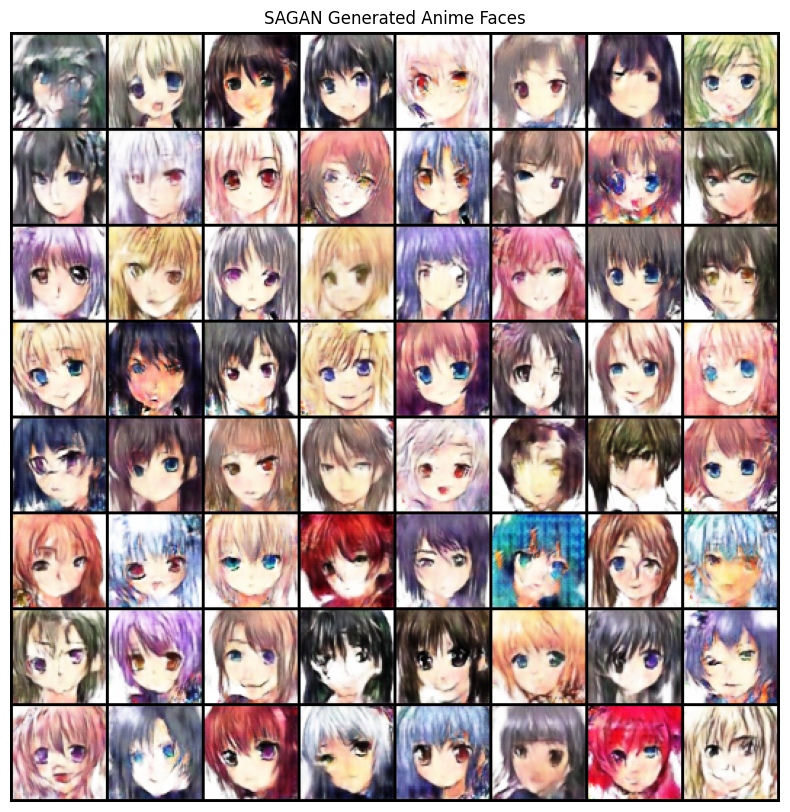

In [10]:
# ============================================================
# SECTION 9 — FINAL IMAGE MATRIX
# ============================================================

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("SAGAN Generated Anime Faces")
plt.imshow(grid.permute(1, 2, 0))
plt.show()